# Resultados do relatório — Projeto Integrador I, Grupo IV

**Padrões de ocorrências SAR e situação das pessoas envolvidas** · MBA em IA e Ciência de Dados para Transformação Digital na Defesa (FGV/EMAP)

Este notebook reproduz, na ordem do relatório, todos os números, tabelas e figuras apresentados no texto. Cada título indica a seção do relatório correspondente, e a última seção confere os valores calculados com os valores publicados no relatório.

**Arquivos lidos** (pasta `dados/`)

| Arquivo | Uso |
|---|---|
| `SAR_2021-2025_consolidado.xlsx` | Aba "Base de dados", com um evento SAR por linha, e abas de resumo com os valores publicados no ANEMAR |
| `SAR_2021-2025_validacao.xlsx` | Registro das alterações feitas na preparação da base (seções 3.2 e 3.4) |
| `areas/*.json` | Áreas dos Distritos Navais, usadas nos mapas |

**Arquivos gerados** (pasta `resultados/`): tabelas em CSV (separador `;` e vírgula decimal, para abrir direto no Excel), figuras em PNG e mapas em HTML.

**Como executar**, na raiz do repositório:

```bash
pip install -r requirements.txt matplotlib notebook
jupyter notebook resultados_relatorio.ipynb
```

e depois *Executar tudo*.

As regras de cálculo são as mesmas do painel (`dados_sar.py`). As figuras do relatório são capturas do painel; aqui os gráficos são refeitos em matplotlib, com os mesmos números e as mesmas cores, e os mapas usam o Folium, como no painel.

## 0. Preparação

Bibliotecas, caminhos dos arquivos, cores e pequenas funções usadas ao longo do notebook.

In [1]:
from pathlib import Path
import json

import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, Normalize

# Caminhos
PASTA_DADOS = Path("dados")
PASTA_RESULTADOS = Path("resultados")
PASTA_RESULTADOS.mkdir(exist_ok=True)

ARQUIVO_BASE = PASTA_DADOS / "SAR_2021-2025_consolidado.xlsx"
ARQUIVO_VALIDACAO = PASTA_DADOS / "SAR_2021-2025_validacao.xlsx"

# Cores do painel: vermelho é sempre óbito ou desaparecido e azul é sempre
# sobrevivente ou vida salva (par distinguível também com daltonismo).
COR_GRAVE = "#d03b3b"
COR_SALVAS = "#2a78d6"
COR_SEM_REGISTRO = "#8a8984"
COR_SUSPENSO = "#d95926"
CORES_SITUACAO = {
    "Com óbito ou desaparecido": COR_GRAVE,
    "Somente sobreviventes": COR_SALVAS,
    "Sem registro de pessoas": COR_SEM_REGISTRO,
}

MESES = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

# Aparência dos gráficos: grade discreta e sem bordas desnecessárias.
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.edgecolor": "#b0b0ab",
    "grid.color": "#e4e4e0",
})
pd.set_option("display.max_colwidth", None)


def numero(valor):
    """Formata um número inteiro no padrão brasileiro (ex.: 1.391)."""
    return f"{int(valor):,}".replace(",", ".")


def salvar_tabela(tabela, nome):
    """Grava a tabela em CSV no padrão do Excel em português (; e vírgula decimal)."""
    tabela.to_csv(PASTA_RESULTADOS / f"{nome}.csv", sep=";", decimal=",", encoding="utf-8-sig")


def salvar_figura(figura, nome):
    figura.savefig(PASTA_RESULTADOS / f"{nome}.png", dpi=150, bbox_inches="tight")

### Leitura da base

A base é lida da aba "Base de dados". O quadro `base` guarda a planilha como está; o quadro `df` recebe nomes curtos para as colunas usadas e as medidas do projeto (seção 3.5 do relatório):

- **Sobreviventes** = vidas salvas pela MB + vidas salvas por meios extra-MB + sobreviventes sem resgate.
- **Óbitos** = coluna `ÓBITOS`; **desaparecidos** = coluna `VIDAS AINDA DESAPARECIDAS`.
- Células vazias nas colunas de pessoas contam como zero.
- Cada evento entra em um de três grupos: com ao menos um óbito ou desaparecido, somente sobreviventes, ou sem registro de pessoas.

In [2]:
base = pd.read_excel(ARQUIVO_BASE, sheet_name="Base de dados")

# Nomes curtos para as colunas usadas nas análises (os mesmos do painel).
COLUNAS = {
    "IDENTIFICADOR SAR": "identificador",
    "ANO": "ano",
    "SALVAMAR (RCC)": "rcc",
    "Nº EVT SAR": "numero_evento",
    "DISTRITO NAVAL": "distrito_naval",
    "SALVAMAR": "salvamar",
    "DATA ABERTURA": "data_abertura",
    "SITUAÇÃO DO EVENTO": "situacao_evento",
    "CICLOS DO EVENTO": "ciclos",
    "DURAÇÃO (DIAS)": "duracao",
    "TIPO INCIDENTE (ANEMAR)": "tipo_incidente",
    "CLASSE DA EMBARCAÇÃO": "classe_embarcacao",
    "RSC (PADRONIZADO)": "om_responsavel",
    "LATITUDE (GD)": "latitude",
    "LONGITUDE (GD)": "longitude",
    "SITUAÇÃO COORDENADA": "situacao_coordenada",
    "VIDAS SALVAS MB": "salvas_mb",
    "VIDAS SALVAS EXTRA-MB": "salvas_extra_mb",
    "SOBREVIVENTES SEM RESGATE": "sem_resgate",
    "ÓBITOS": "obitos",
    "VIDAS AINDA DESAPARECIDAS": "desaparecidos",
}
PESSOAS = ["salvas_mb", "salvas_extra_mb", "sem_resgate", "obitos", "desaparecidos"]

df = base.rename(columns=COLUNAS)
df[PESSOAS] = df[PESSOAS].fillna(0).astype(int)

df["vidas_salvas"] = df["salvas_mb"] + df["salvas_extra_mb"]
df["sobreviventes"] = df["vidas_salvas"] + df["sem_resgate"]
df["grave"] = (df["obitos"] > 0) | (df["desaparecidos"] > 0)  # ao menos um óbito ou desaparecido
df["situacao_pessoas"] = np.select(
    [df["grave"], df["sobreviventes"] > 0],
    ["Com óbito ou desaparecido", "Somente sobreviventes"],
    default="Sem registro de pessoas",
)
df["mes"] = df["data_abertura"].dt.month
df["numero_distrito"] = df["distrito_naval"].str.extract(r"(\d+)", expand=False).astype(int)

# Salvamares na ordem dos Distritos Navais (1º DN, 2º DN, ...).
ORDEM_SALVAMARES = df.sort_values("numero_distrito")["salvamar"].unique().tolist()

# Planilha de validação: todas as abas, em um dicionário {nome da aba: tabela}.
validacao = pd.read_excel(ARQUIVO_VALIDACAO, sheet_name=None)

print(f"{numero(len(df))} eventos SAR de {df['ano'].min()} a {df['ano'].max()}, {base.shape[1]} colunas")

1.391 eventos SAR de 2021 a 2025, 83 colunas


## 1.4 Relevância — Tabela 2: eventos SAR e pessoas envolvidas por ano

Vidas salvas = salvas por meios da MB + salvas por meios extra-MB. Os sobreviventes sem resgate só são registrados desde 2023 e aparecem vazios (`<NA>`) em 2021 e 2022.

In [3]:
tabela2 = df.groupby("ano").agg(
    eventos=("identificador", "size"),
    vidas_salvas=("vidas_salvas", "sum"),
    sem_resgate=("sem_resgate", "sum"),
    obitos=("obitos", "sum"),
    desaparecidos=("desaparecidos", "sum"),
    eventos_com_obito_ou_desap=("grave", "sum"),
)
tabela2.index = tabela2.index.astype(str)
tabela2.loc["Total"] = tabela2.sum()
tabela2 = tabela2.astype("Int64")
tabela2.loc[["2021", "2022"], "sem_resgate"] = pd.NA  # campo registrado só desde 2023

tabela2.columns = ["Eventos", "Vidas salvas", "Sobreviventes sem resgate", "Óbitos",
                   "Desaparecidos", "Eventos com óbito ou desap."]
salvar_tabela(tabela2, "tabela2_eventos_e_pessoas_por_ano")
tabela2

,Eventos,Vidas salvas,Sobreviventes sem resgate,Óbitos,Desaparecidos,Eventos com óbito ou desap.
ano,,,,,,
2021,305,706,<NA>,183,68,174
2022,257,615,<NA>,177,60,148
2023,295,644,87,148,63,166
2024,270,405,45,162,29,136
2025,264,661,39,151,40,147
Total,1391,3031,171,821,260,771


In [4]:
total_eventos = len(df)
eventos_graves = int(df["grave"].sum())

print(f"Eventos: {numero(total_eventos)}")
print(f"Sobreviventes: {numero(df['sobreviventes'].sum())}")
print(f"  vidas salvas: {numero(df['vidas_salvas'].sum())} "
      f"(MB {numero(df['salvas_mb'].sum())} + extra-MB {numero(df['salvas_extra_mb'].sum())})")
print(f"  sobreviventes sem resgate: {numero(df['sem_resgate'].sum())}")
print(f"Óbitos: {numero(df['obitos'].sum())}")
print(f"Desaparecidos: {numero(df['desaparecidos'].sum())}")
print(f"Eventos com ao menos um óbito ou desaparecido: {numero(eventos_graves)} "
      f"({100 * eventos_graves / total_eventos:.0f}%)")

Eventos: 1.391
Sobreviventes: 3.202
  vidas salvas: 3.031 (MB 978 + extra-MB 2.053)
  sobreviventes sem resgate: 171
Óbitos: 821
Desaparecidos: 260
Eventos com ao menos um óbito ou desaparecido: 771 (55%)


## 2.3 O que fica fora do escopo — preenchimento dos campos por ano

Percentual de eventos com o campo preenchido, por ano. Mostra por que comprimento, distância da costa, tipo de acionamento e uso de colete ficaram fora do painel (seções 2.3, 3.6 e 6.3): o comprimento passa das classes próprias (até 2024) para as faixas do ANEMAR (2025), a distância da costa alterna entre valor e faixas, o tipo de acionamento só é sistemático desde 2023 e o colete é quase sempre vazio. A coluna `SOBREVIVENTES` só é preenchida em 2024 e 2025.

In [5]:
CAMPOS_REGISTRO = [
    "TIPO DE ACIONAMENTO",
    "COMPRIMENTO EMB SINISTRADA",          # classes próprias (até 2024)
    "COMPRIMENTO - 0 a 15mts",             # primeira faixa do ANEMAR (2025)
    "DISTÂNCIA LINHA DE COSTA",            # valor em milhas
    "DISTÂNCIA LINHA DE COSTA (FAIXAS)",   # faixas
    "USO DE COLETE SALVAVIDAS",
    "SOBREVIVENTES",
]
preenchimento = (100 * base.groupby("ANO")[CAMPOS_REGISTRO].agg(lambda c: c.notna().mean())).round(0).T
salvar_tabela(preenchimento, "preenchimento_dos_campos_por_ano")
preenchimento

ANO,2021,2022,2023,2024,2025
TIPO DE ACIONAMENTO,2.0,53.0,99.0,100.0,100.0
COMPRIMENTO EMB SINISTRADA,78.0,51.0,96.0,98.0,0.0
COMPRIMENTO - 0 a 15mts,0.0,0.0,0.0,0.0,81.0
DISTÂNCIA LINHA DE COSTA,79.0,27.0,3.0,79.0,97.0
DISTÂNCIA LINHA DE COSTA (FAIXAS),0.0,68.0,100.0,96.0,98.0
USO DE COLETE SALVAVIDAS,14.0,14.0,1.0,0.0,0.0
SOBREVIVENTES,0.0,0.0,0.0,100.0,99.0


## 3.2 Base tratada — Tabela 3: principais tratamentos aplicados

As cinco planilhas anuais foram padronizadas com as mesmas 84 colunas, listadas no dicionário de dados da planilha consolidada. Na versão final, a coluna `OPERADOR CONSAR` foi retirada (seção 3.7), e a aba "Base de dados" ficou com 83 colunas.

As quantidades de grafias vêm da própria base (coluna original × coluna padronizada). As demais vêm da planilha de validação, que registra cada alteração com a sua fonte.

In [6]:
dicionario = pd.read_excel(ARQUIVO_BASE, sheet_name="DICIONÁRIO DE DADOS")
print(f"Colunas das planilhas anuais (dicionário de dados): {len(dicionario)}")
print(f"Colunas da aba 'Base de dados': {base.shape[1]}")
print(f"Coluna OPERADOR CONSAR presente na base: {'OPERADOR CONSAR' in base.columns}")

Colunas das planilhas anuais (dicionário de dados): 84
Colunas da aba 'Base de dados': 83
Coluna OPERADOR CONSAR presente na base: False


In [7]:
registro = validacao["REGISTRO DE ALTERAÇÕES"]
tipo = registro["TIPO"]
rodadas_2_a_4 = ~registro["RODADA"].str.startswith("1ª")

tabela3 = pd.DataFrame([
    ("Tipos de incidente",
     f"{base['TIPO INCIDENTE'].nunique()} grafias consolidadas nas "
     f"{base['TIPO INCIDENTE (ANEMAR)'].nunique()} categorias do ANEMAR"),
    ("Tipos de embarcação",
     f"{base['TIPO DE EMBARCAÇÃO'].nunique()} grafias reduzidas a "
     f"{base['TIPO DE EMBARCAÇÃO (PADRONIZADO)'].nunique()} tipos, agrupados em "
     f"{base['CLASSE DA EMBARCAÇÃO'].nunique()} classes"),
    ("Nomenclatura das OM",
     f"{validacao['NOMENCLATURA DAS OM']['REGISTROS'].sum()} ajustes de sigla, conforme o Organograma da MB"),
    ("Coordenadas",
     f"{(tipo == 'Correção de coordenada').sum() + (tipo == 'Correção de coordenada decimal').sum()} correções: "
     f"{(tipo == 'Correção de coordenada').sum()} pela posição informada no relatório final ou nas mensagens e "
     f"{(tipo == 'Correção de coordenada decimal').sum()} pelo texto da própria linha"),
    ("Datas e campos",
     f"{((tipo == 'Correção de registro') & rodadas_2_a_4).sum()} correções e "
     f"{(tipo == 'Preenchimento de data').sum()} datas preenchidas a partir das mensagens"),
    ("Registros duplicados",
     f"{tipo.isin(['Reorganização de registro', 'Reconstrução de registro']).sum()} correções em 2024, "
     "com os eventos ausentes reconstruídos pelas mensagens"),
    ("Leitura das mensagens",
     f"{len(validacao['ANDAMENTO PELAS MENSAGENS'])} eventos revisados mensagem a mensagem"),
], columns=["Tratamento", "Resultado"]).set_index("Tratamento")

print(f"Alterações documentadas na planilha de validação: {len(registro)}")
salvar_tabela(tabela3, "tabela3_tratamentos")
tabela3

Alterações documentadas na planilha de validação: 659


,Resultado
Tratamento,
Tipos de incidente,66 grafias consolidadas nas 9 categorias do ANEMAR
Tipos de embarcação,"168 grafias reduzidas a 30 tipos, agrupados em 9 classes"
Nomenclatura das OM,"600 ajustes de sigla, conforme o Organograma da MB"
Coordenadas,61 correções: 52 pela posição informada no relatório final ou nas mensagens e 9 pelo texto da própria linha
Datas e campos,67 correções e 48 datas preenchidas a partir das mensagens
Registros duplicados,"3 correções em 2024, com os eventos ausentes reconstruídos pelas mensagens"
Leitura das mensagens,242 eventos revisados mensagem a mensagem


## 3.3 Situação dos eventos

A situação final segue a doutrina (encerrado ou suspenso). A coluna `CICLOS DO EVENTO` descreve os eventos com suspensões ou reaberturas sucessivas. A duração é o número de dias entre a abertura e o último acontecimento registrado.

In [8]:
print(df["situacao_evento"].value_counts().to_string())
print(f"\nEventos com sequência mais longa (CICLOS DO EVENTO preenchido): {df['ciclos'].notna().sum()}")

situacao_evento
Encerrado    1203
Suspenso      188

Eventos com sequência mais longa (CICLOS DO EVENTO preenchido): 23


## 3.4 Qualidade e cobertura

Comparação da base com o Anuário de Estatística SAR (ANEMAR). Os valores publicados no ANEMAR estão nas abas de resumo da planilha consolidada e na aba "SEQUÊNCIA POR RCC" da planilha de validação.

In [9]:
# Total de eventos por ano: base x ANEMAR
anemar_ano = pd.read_excel(ARQUIVO_BASE, sheet_name="TOTAL POR ANO")
anemar_ano = anemar_ano[anemar_ano["ANO"] != "TOTAL"].astype({"ANO": int}).set_index("ANO")
por_ano = pd.DataFrame({
    "Base": df["ano"].value_counts().sort_index(),
    "ANEMAR": anemar_ano["PUBLICADO NO ANEMAR"],
})
print(por_ano.to_string())
print(f"Total: base {numero(por_ano['Base'].sum())} x ANEMAR {numero(por_ano['ANEMAR'].sum())}\n")

# 45 combinações de ano e Distrito Naval (Salvamar)
sequencia = validacao["SEQUÊNCIA POR RCC"].set_index(["ANO", "RCC"])
combinacoes = df.groupby(["ano", "rcc"]).size().rename("base").to_frame()
combinacoes["anemar"] = sequencia["PUBLICADO NO ANEMAR"].reindex(combinacoes.index).values
iguais = (combinacoes["base"] == combinacoes["anemar"]).sum()
print(f"Combinações de ano e Distrito Naval: {len(combinacoes)}, iguais ao ANEMAR: {iguais}")

# Sequência numérica de cada Salvamar em cada ano: começa em 1, sem lacunas e sem repetições
seq = df.groupby(["ano", "rcc"])["numero_evento"].agg(["count", "min", "max", "nunique"])
completas = (seq["min"] == 1) & (seq["max"] == seq["count"]) & (seq["nunique"] == seq["count"])
print(f"Sequências completas e sem repetição: {completas.sum()} de {len(seq)}")

# Eventos conferidos com o relatório final (SITREP FINAL)
conferidos = (validacao["CONFERÊNCIA COM O DRIVE"]["SITREP LOCALIZADO"] == "Sim").sum()
print(f"Eventos conferidos com o relatório final: {numero(conferidos)} ({100 * conferidos / total_eventos:.0f}%)")

# Posição
sem_posicao = df[["latitude", "longitude"]].isna().any(axis=1).sum()
print(f"\nEventos sem posição utilizável: {sem_posicao}")
print(df["situacao_coordenada"].value_counts().to_string())

      Base  ANEMAR
2021   305     305
2022   257     257
2023   295     295
2024   270     270
2025   264     264
Total: base 1.391 x ANEMAR 1.391

Combinações de ano e Distrito Naval: 45, iguais ao ANEMAR: 45
Sequências completas e sem repetição: 45 de 45
Eventos conferidos com o relatório final: 1.216 (87%)

Eventos sem posição utilizável: 0
situacao_coordenada
OK                                                                           1388
aproximada — a origem informava só graus inteiros                               2
aproximada — Ilha de Paquetá, local citado nas mensagens (sem coordenada)       1


**Tipo de incidente.** O ANEMAR de 2021 usava menos categorias e lançava em "Outros" registros que a base classifica pela tabela usada de 2022 em diante; nos demais anos há diferenças pontuais de enquadramento. A soma das diferenças de cada ano é zero, ou seja, o total do ano não muda.

In [10]:
anemar_categoria = pd.read_excel(ARQUIVO_BASE, sheet_name="TOTAL POR CATEGORIA E ANO")
anemar_categoria = anemar_categoria.set_index("CATEGORIA (ANEMAR)").drop("TOTAL")
categorias = pd.DataFrame({
    "Base": df["tipo_incidente"].value_counts(),
    "ANEMAR": anemar_categoria["PUBLICADO NO ANEMAR"],
})
categorias["Diferença"] = categorias["Base"] - categorias["ANEMAR"]
print(categorias.sort_values("Base", ascending=False).to_string())

reconciliacao = pd.read_excel(ARQUIVO_BASE, sheet_name="RECONCILIAÇÃO COM O ANEMAR")
print("\nSoma das diferenças por categoria, em cada ano:")
print(reconciliacao.groupby("ANO")["DIFERENÇA"].sum().to_string())

                                                   Base  ANEMAR  Diferença
Homem ao mar                                        404     395          9
Naufrágio / emborcamento                            366     347         19
Avaria / à deriva                                   199     193          6
Desaparecimento / perda de contato com embarcação   174     148         26
Orientação / evacuação médica                       150     151         -1
Colisão / abalroamento                               52      51          1
Outros                                               25      86        -61
Incêndio / explosão                                  14      14          0
Encalhe                                               7       6          1



Soma das diferenças por categoria, em cada ano:
ANO
2021    0
2022    0
2023    0
2024    0
2025    0


**Contagens de pessoas.** São um pouco diferentes das publicadas no ANEMAR; o projeto usa os valores da base. A comparação por ano e Salvamar está na aba "SOBREVIVENTES, DESAPAR., ÓBITOS" da planilha consolidada.

In [11]:
resumo_pessoas = pd.read_excel(ARQUIVO_BASE, sheet_name="SOBREVIVENTES, DESAPAR., ÓBITOS")
anemar_total = resumo_pessoas.set_index("ANO").loc["TOTAL 2021-2025"]

pessoas_anemar = pd.DataFrame({
    "Base": [df["sobreviventes"].sum(), df["obitos"].sum(), df["desaparecidos"].sum()],
    "ANEMAR": [anemar_total["SOBREVIVENTES NO ANEMAR"], anemar_total["ÓBITOS NO ANEMAR"],
               anemar_total["DESAPARECIDOS NO ANEMAR"]],
}, index=["Sobreviventes", "Óbitos", "Desaparecidos"])
pessoas_anemar

,Base,ANEMAR
Sobreviventes,3202,3291
Óbitos,821,842
Desaparecidos,260,248


## 3.5 Medidas de pessoas

Células vazias nas colunas de pessoas (antes de serem tratadas como zero) e a divisão dos eventos nos três grupos que definem as cores do painel. Nas colunas de vidas salvas, óbitos e desaparecidos, as células vazias ocorrem em no máximo 4 eventos. A coluna de sobreviventes sem resgate fica vazia em 2021 e 2022, porque o campo ainda não era registrado, e também em parte dos eventos de 2023 a 2025.

In [12]:
colunas_pessoas = ["VIDAS SALVAS MB", "VIDAS SALVAS EXTRA-MB", "SOBREVIVENTES SEM RESGATE",
                   "ÓBITOS", "VIDAS AINDA DESAPARECIDAS"]
vazias = pd.DataFrame({
    "2021-2022": base[base["ANO"] <= 2022][colunas_pessoas].isna().sum(),
    "2023-2025": base[base["ANO"] >= 2023][colunas_pessoas].isna().sum(),
})
vazias["Total"] = vazias.sum(axis=1)
print("Células vazias por coluna:")
print(vazias.to_string())

grupos = df["situacao_pessoas"].value_counts().reindex(CORES_SITUACAO)
print("\nEventos por grupo:")
print(grupos.to_string())

Células vazias por coluna:
                           2021-2022  2023-2025  Total
VIDAS SALVAS MB                    1          2      3
VIDAS SALVAS EXTRA-MB              1          2      3
SOBREVIVENTES SEM RESGATE        562         81    643
ÓBITOS                             1          2      3
VIDAS AINDA DESAPARECIDAS          1          3      4

Eventos por grupo:
situacao_pessoas
Com óbito ou desaparecido    771
Somente sobreviventes        558
Sem registro de pessoas       62


## 3.6 Limitações — uso de colete salva-vidas

Percentual de eventos com o campo de uso de colete preenchido.

In [13]:
colete = base["USO DE COLETE SALVAVIDAS"].notna()
print(f"2021 e 2022: {100 * colete[base['ANO'] <= 2022].mean():.0f}%")
print(f"2023 a 2025: {100 * colete[base['ANO'] >= 2023].mean():.1f}%".replace(".", ","))
print("\nPor ano (%):")
print((100 * colete.groupby(base["ANO"]).mean()).round(1).to_string())

2021 e 2022: 14%


2023 a 2025: 0,7%

Por ano (%):
ANO
2021    13.8
2022    14.0
2023     1.4
2024     0.4
2025     0.4


## 4.1 Áreas dos Distritos Navais

Tamanho dos arquivos GeoJSON antes e depois da simplificação feita pelo script `preparar_areas.py` do repositório (algoritmo de Ramer-Douglas-Peucker, tolerância de 0,005 grau, cerca de 550 metros).

In [14]:
def tamanho_da_pasta(pasta):
    return sum(arquivo.stat().st_size for arquivo in Path(pasta).glob("*.json"))

originais = PASTA_DADOS / "areas_originais"
if originais.exists():
    print(f"Arquivos originais: {tamanho_da_pasta(originais) / 1e6:.0f} MB")
print(f"Arquivos simplificados: {tamanho_da_pasta(PASTA_DADOS / 'areas') / 1e3:.0f} KB")

Arquivos originais: 15 MB
Arquivos simplificados: 278 KB


## 4.2 Figura 2 — Mapa dos incidentes

Posição de cada evento SAR, colorida pela situação das pessoas envolvidas, sobre as áreas dos nove Distritos Navais. O mapa é gravado em `resultados/figura2_mapa_incidentes.html` e pode ser aberto em qualquer navegador (os blocos do OpenStreetMap precisam de internet).

In [15]:
# Cor de cada área: quatro cores para nove áreas, com Distritos vizinhos em cores
# diferentes (a mesma regra do painel).
CORES_AREAS = {1: "#eda100", 2: "#1baf7a", 3: "#eda100", 4: "#4a3aa7", 5: "#eda100",
               6: "#1baf7a", 7: "#e87ba4", 8: "#4a3aa7", 9: "#eda100"}


def adicionar_areas(mapa):
    """Desenha a área de cada Distrito Naval, com o nome do Salvamar ao passar o mouse."""
    salvamar_do_distrito = dict(df[["numero_distrito", "salvamar"]].drop_duplicates().values)
    for arquivo in sorted((PASTA_DADOS / "areas").glob("*.json")):
        area = json.loads(arquivo.read_text(encoding="utf-8"))
        distrito = int(area["features"][0]["properties"]["id_dn"])
        cor = CORES_AREAS[distrito]
        folium.GeoJson(
            area,
            style_function=lambda _, cor=cor: {"color": cor, "weight": 2, "fillColor": cor, "fillOpacity": 0.08},
            tooltip=f"{distrito}º DN — {salvamar_do_distrito[distrito]}",
        ).add_to(mapa)


def adicionar_legenda(mapa, linhas):
    """Quadro no canto inferior esquerdo do mapa."""
    html = ("<div style='position:fixed; bottom:25px; left:10px; z-index:1000; background:white;"
            " padding:8px 12px; border-radius:6px; box-shadow:0 1px 4px rgba(0,0,0,.3);"
            " font:13px sans-serif; line-height:1.6'>" + "<br>".join(linhas) + "</div>")
    mapa.get_root().html.add_child(folium.Element(html))


mapa_incidentes = folium.Map(location=[-15, -45], zoom_start=4, tiles="OpenStreetMap")
adicionar_areas(mapa_incidentes)

# Os eventos com óbito ou desaparecido são desenhados por último, para ficarem por cima.
for situacao in reversed(list(CORES_SITUACAO)):
    for _, evento in df[df["situacao_pessoas"] == situacao].iterrows():
        folium.CircleMarker(
            location=[evento["latitude"], evento["longitude"]],
            radius=5, color="white", weight=1,
            fill=True, fill_color=CORES_SITUACAO[situacao], fill_opacity=0.9,
            tooltip=f"{evento['identificador']} | {evento['tipo_incidente']}",
        ).add_to(mapa_incidentes)

adicionar_legenda(mapa_incidentes, [f"<b>{numero(len(df))} incidentes no mapa</b>"] + [
    f"<span style='color:{cor}; font-size:16px'>●</span> {situacao}: {numero(grupos[situacao])}"
    for situacao, cor in CORES_SITUACAO.items()
])
mapa_incidentes.save(PASTA_RESULTADOS / "figura2_mapa_incidentes.html")
print("Mapa gravado em resultados/figura2_mapa_incidentes.html")

Mapa gravado em resultados/figura2_mapa_incidentes.html


## 5.1 Quando as ocorrências acontecem

### Figura 3 — Total de eventos por mês, somados os cinco anos

Mês com menos eventos: Fev (98)
Mês com mais eventos: Out (136)


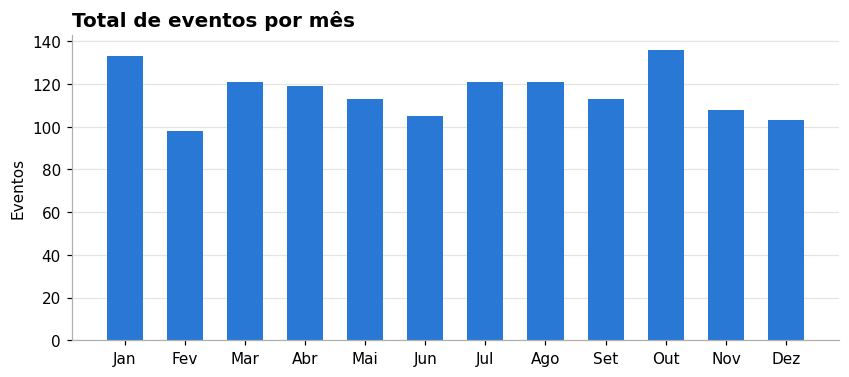

In [16]:
por_mes = df["mes"].value_counts().reindex(range(1, 13), fill_value=0)
por_mes.index = MESES

print(f"Mês com menos eventos: {por_mes.idxmin()} ({por_mes.min()})")
print(f"Mês com mais eventos: {por_mes.idxmax()} ({por_mes.max()})")

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(por_mes.index, por_mes.values, color=COR_SALVAS, width=0.6)
ax.set_title("Total de eventos por mês")
ax.set_ylabel("Eventos")
ax.grid(axis="y")
ax.set_axisbelow(True)
salvar_figura(fig, "figura3_eventos_por_mes")
plt.show()

### Figura 4 — Índice sazonal por Salvamar

- **Índice sazonal:** eventos do mês, somados os anos, divididos pela média mensal do próprio Salvamar. O valor 1 corresponde à média e 1,5 a 50% acima dela.
- **Anos acima da média:** em quantos anos aquele mês ficou acima da média mensal do Salvamar naquele ano. Separa o padrão que se repete do episódio isolado.

In [17]:
anos = sorted(df["ano"].unique())

# Grade completa Salvamar x ano x mês, para que meses sem evento contem como zero.
grade = pd.MultiIndex.from_product([ORDEM_SALVAMARES, anos, range(1, 13)],
                                   names=["salvamar", "ano", "mes"]).to_frame(index=False)
contagem = df.groupby(["salvamar", "ano", "mes"]).size().rename("eventos").reset_index()
por_ano_mes = grade.merge(contagem, how="left").fillna({"eventos": 0})

# O mês ficou acima da média mensal do Salvamar naquele ano?
media_do_ano = por_ano_mes.groupby(["salvamar", "ano"])["eventos"].transform("mean")
por_ano_mes["acima_da_media"] = por_ano_mes["eventos"] > media_do_ano

sazonal = por_ano_mes.groupby(["salvamar", "mes"]).agg(
    eventos=("eventos", "sum"), anos_acima=("acima_da_media", "sum")
).reset_index()
sazonal["indice"] = sazonal["eventos"] / sazonal.groupby("salvamar")["eventos"].transform("mean")

indice = sazonal.pivot(index="salvamar", columns="mes", values="indice").loc[ORDEM_SALVAMARES]
anos_acima = sazonal.pivot(index="salvamar", columns="mes", values="anos_acima").loc[ORDEM_SALVAMARES]
indice.columns = anos_acima.columns = MESES

salvar_tabela(indice.round(2), "figura4_indice_sazonal")
salvar_tabela(anos_acima, "figura4_anos_acima_da_media")
indice.round(1)

,Jan,Fev,Mar,Abr,Mai,Jun,Jul,Ago,Set,Out,Nov,Dez
salvamar,,,,,,,,,,,,
SALVAMAR SUESTE,1.5,0.9,1.2,0.8,0.7,0.6,1.2,0.7,0.8,1.3,1.2,0.9
SALVAMAR LESTE,1.9,0.6,0.7,1.0,1.2,1.1,0.8,1.0,1.1,1.2,0.8,0.8
SALVAMAR NORDESTE,0.6,0.8,1.2,1.3,1.5,1.2,1.5,1.0,0.8,0.7,0.7,0.7
SALVAMAR NORTE,0.8,1.1,0.9,1.1,1.1,0.8,1.3,0.9,1.0,1.4,0.8,0.9
SALVAMAR SUL,1.2,0.8,0.9,0.4,0.8,0.9,0.8,1.1,0.8,1.2,1.5,1.5
SALVAMAR OESTE,0.5,0.8,1.4,1.4,0.5,0.8,1.1,1.6,1.6,0.8,0.8,0.5
SALVAMAR CENTRO-OESTE,1.4,1.1,1.4,0.4,1.4,1.4,0.7,0.4,1.1,1.4,0.4,1.1
SALVAMAR SUL-SUESTE,1.0,0.6,1.1,1.1,1.0,1.1,0.6,1.2,1.1,1.2,1.0,0.9
SALVAMAR NOROESTE,1.1,0.9,1.1,1.6,0.8,0.8,1.2,1.8,0.9,0.8,0.5,0.5


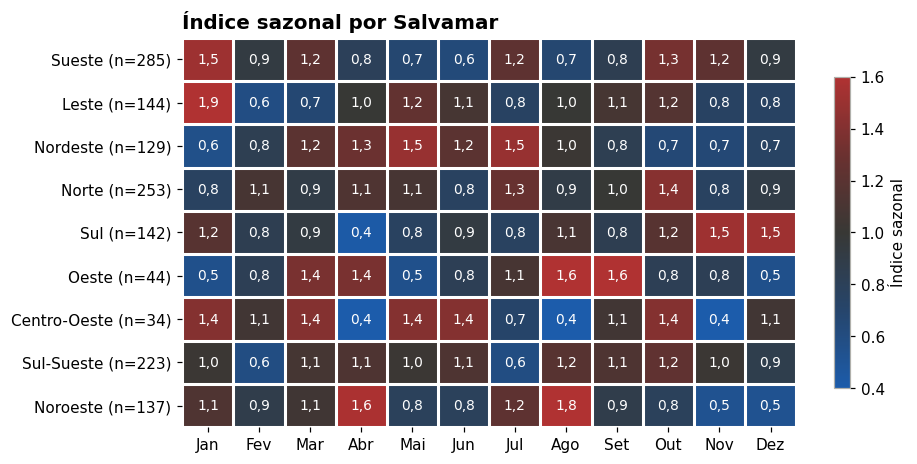

In [18]:
# Escala divergente do painel: azul abaixo da média, cinza na média, vermelho acima.
escala = LinearSegmentedColormap.from_list("sazonal", [
    (0.00, "#1c5cab"), (0.25, "#26456b"), (0.50, "#383835"), (0.75, "#6b3130"), (1.00, "#b03232"),
])
normalizar = Normalize(vmin=0.4, vmax=1.6, clip=True)

total_por_salvamar = df["salvamar"].value_counts()
rotulos = [f"{s.replace('SALVAMAR ', '').title()} (n={total_por_salvamar[s]})" for s in ORDEM_SALVAMARES]

fig, ax = plt.subplots(figsize=(9, 4.6))
imagem = ax.imshow(indice.values, cmap=escala, norm=normalizar, aspect="auto")
for linha in range(indice.shape[0]):
    for coluna in range(indice.shape[1]):
        ax.text(coluna, linha, f"{indice.iat[linha, coluna]:.1f}".replace(".", ","),
                ha="center", va="center", color="white", fontsize=9)

# Linhas brancas entre as células
ax.set_xticks(np.arange(-0.5, 12), minor=True)
ax.set_yticks(np.arange(-0.5, len(rotulos)), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", length=0)
for lado in ax.spines.values():
    lado.set_visible(False)

ax.set_xticks(range(12), MESES)
ax.set_yticks(range(len(rotulos)), rotulos)
ax.set_title("Índice sazonal por Salvamar")
fig.colorbar(imagem, ax=ax, shrink=0.8, label="Índice sazonal")
salvar_figura(fig, "figura4_indice_sazonal")
plt.show()

**Picos que se repetem.** O relatório destaca (i) os meses acima da média nos cinco anos e (ii) os meses acima da média em quatro dos cinco anos com índice de pelo menos 1,4. Os Salvamares OESTE e CENTRO-OESTE, com poucos eventos, ficam de fora do segundo grupo porque o índice oscila muito de um mês para outro.

In [19]:
colunas = ["salvamar", "mes", "eventos", "indice", "anos_acima"]
poucos_eventos = ["SALVAMAR OESTE", "SALVAMAR CENTRO-OESTE"]

nos_cinco_anos = sazonal[sazonal["anos_acima"] == len(anos)]
em_quatro_anos = sazonal[(sazonal["anos_acima"] == len(anos) - 1) & (sazonal["indice"] >= 1.4)
                         & ~sazonal["salvamar"].isin(poucos_eventos)]

print("Acima da média nos cinco anos:")
print(nos_cinco_anos[colunas].round(1).to_string(index=False))
print("\nAcima da média em quatro dos cinco anos, com índice de pelo menos 1,4:")
print(em_quatro_anos[colunas].round(1).to_string(index=False))
print("\nEventos no período:", total_por_salvamar[poucos_eventos].to_dict())

Acima da média nos cinco anos:
         salvamar  mes  eventos  indice  anos_acima
SALVAMAR NOROESTE    8     21.0     1.8           5
  SALVAMAR SUESTE    1     36.0     1.5           5
  SALVAMAR SUESTE   10     32.0     1.3           5

Acima da média em quatro dos cinco anos, com índice de pelo menos 1,4:
         salvamar  mes  eventos  indice  anos_acima
   SALVAMAR LESTE    1     23.0     1.9           4
SALVAMAR NORDESTE    5     16.0     1.5           4
SALVAMAR NORDESTE    7     16.0     1.5           4
   SALVAMAR NORTE   10     30.0     1.4           4
     SALVAMAR SUL   11     18.0     1.5           4
     SALVAMAR SUL   12     18.0     1.5           4

Eventos no período: {'SALVAMAR OESTE': 44, 'SALVAMAR CENTRO-OESTE': 34}


## 5.2 Onde as ocorrências se repetem

A área de busca é dividida em células de 0,5° de lado (cerca de 55 km). Uma célula é **recorrente** quando tem ao menos um evento em cada um dos cinco anos. Para cada célula, a OM responsável, o Salvamar e o tipo de incidente são os mais frequentes entre os seus eventos (em caso de empate, vale o primeiro em ordem alfabética, como no painel).

In [20]:
LADO_CELULA = 0.5

celulas_df = df.assign(
    celula_x=np.floor(df["longitude"] / LADO_CELULA),
    celula_y=np.floor(df["latitude"] / LADO_CELULA),
)


def mais_frequente(serie):
    return serie.mode().iat[0]


celulas = celulas_df.groupby(["celula_x", "celula_y"]).agg(
    eventos=("identificador", "size"),
    anos=("ano", "nunique"),
    proporcao_grave=("grave", "mean"),
    om_responsavel=("om_responsavel", mais_frequente),
    salvamar=("salvamar", mais_frequente),
    tipo_frequente=("tipo_incidente", mais_frequente),
).reset_index()

recorrentes = celulas[celulas["anos"] == len(anos)]
eventos_recorrentes = recorrentes["eventos"].sum()

print(f"Áreas com ocorrência: {len(celulas)}")
print(f"Áreas com eventos nos {len(anos)} anos: {len(recorrentes)} ({100 * len(recorrentes) / len(celulas):.0f}%)")
print(f"Eventos nessas áreas: {eventos_recorrentes} ({100 * eventos_recorrentes / total_eventos:.0f}%)")

Áreas com ocorrência: 577
Áreas com eventos nos 5 anos: 23 (4%)
Eventos nessas áreas: 315 (23%)


### Tabela 5 — Áreas com ocorrências em todos os anos (maior área de cada OM)

O painel lista 15 OM; o relatório mostra as 10 primeiras, com os nomes das OM abreviados.

In [21]:
tabela5 = (
    recorrentes.sort_values("eventos", ascending=False)
    .drop_duplicates("om_responsavel")          # a maior área de cada OM
    .head(15)
    .assign(com_obito_ou_desap=lambda t: (100 * t["proporcao_grave"]).round().astype(int))
    [["om_responsavel", "salvamar", "eventos", "tipo_frequente", "com_obito_ou_desap"]]
    .rename(columns={
        "om_responsavel": "OM responsável pela área",
        "salvamar": "Salvamar",
        "eventos": "Eventos",
        "tipo_frequente": "Tipo mais frequente",
        "com_obito_ou_desap": "Com óbito ou desap. (%)",
    })
    .reset_index(drop=True)
)
tabela5.index = tabela5.index + 1
salvar_tabela(tabela5, "tabela5_areas_recorrentes")
tabela5

,OM responsável pela área,Salvamar,Eventos,Tipo mais frequente,Com óbito ou desap. (%)
1,Delegacia da Capitania dos Portos em Angra dos Reis,SALVAMAR SUESTE,36,Avaria / à deriva,25
2,Capitania dos Portos da Bahia,SALVAMAR LESTE,33,Avaria / à deriva,24
3,Capitania dos Portos do Rio de Janeiro,SALVAMAR SUESTE,31,Avaria / à deriva,26
4,Capitania dos Portos da Amazônia Oriental,SALVAMAR NORTE,16,Naufrágio / emborcamento,69
5,Capitania Fluvial de Santarém,SALVAMAR NORTE,15,Homem ao mar,73
6,Delegacia da Capitania dos Portos em Cabo Frio,SALVAMAR SUESTE,14,Naufrágio / emborcamento,29
7,Capitania dos Portos do Espírito Santo,SALVAMAR SUESTE,12,Avaria / à deriva,25
8,Capitania dos Portos de Macaé,SALVAMAR SUESTE,12,Naufrágio / emborcamento,17
9,Agência da Capitania dos Portos em Paraty,SALVAMAR SUESTE,12,Avaria / à deriva,25
10,Delegacia Fluvial de Presidente Epitácio,SALVAMAR SUL-SUESTE,12,Naufrágio / emborcamento,25


### Figura 5 — Áreas de 0,5° com ocorrência

Cada célula é colorida pela quantidade de eventos. O mapa é gravado em `resultados/figura5_areas_de_ocorrencia.html`.

In [22]:
FAIXAS_CELULAS = [  # (mínimo, máximo, nome, cor): um tom só, do claro ao escuro
    (1, 1, "1 evento", "#86b6ef"),
    (2, 2, "2 eventos", "#5598e7"),
    (3, 5, "3 a 5 eventos", "#2a78d6"),
    (6, 10, "6 a 10 eventos", "#1c5cab"),
    (11, 10**6, "11 ou mais", "#104281"),
]


def cor_da_celula(eventos):
    for minimo, maximo, _, cor in FAIXAS_CELULAS:
        if minimo <= eventos <= maximo:
            return cor


mapa_areas = folium.Map(location=[-15, -45], zoom_start=4, tiles="OpenStreetMap")
for _, celula in celulas.sort_values("eventos").iterrows():
    sul, oeste = celula["celula_y"] * LADO_CELULA, celula["celula_x"] * LADO_CELULA
    cor = cor_da_celula(celula["eventos"])
    folium.Rectangle(
        bounds=[[sul, oeste], [sul + LADO_CELULA, oeste + LADO_CELULA]],
        color=cor, weight=1, fill=True, fill_color=cor, fill_opacity=0.75,
        tooltip=f"{celula['eventos']} eventos em {celula['anos']} ano(s) | {celula['om_responsavel']}",
    ).add_to(mapa_areas)

adicionar_legenda(mapa_areas, ["<b>Eventos por área</b>"] + [
    f"<span style='display:inline-block; width:12px; height:12px; background:{cor};"
    f" margin-right:6px'></span>{nome}" for _, _, nome, cor in FAIXAS_CELULAS
])
mapa_areas.save(PASTA_RESULTADOS / "figura5_areas_de_ocorrencia.html")

print("Células por faixa de eventos:")
for minimo, maximo, nome, _ in FAIXAS_CELULAS:
    print(f"  {nome}: {celulas['eventos'].between(minimo, maximo).sum()}")
print("Mapa gravado em resultados/figura5_areas_de_ocorrencia.html")

Células por faixa de eventos:
  1 evento: 336
  2 eventos: 106
  3 a 5 eventos: 87
  6 a 10 eventos: 29
  11 ou mais: 19
Mapa gravado em resultados/figura5_areas_de_ocorrencia.html


## 5.3 Sobreviventes, óbitos e desaparecidos

Duas medidas usadas em conjunto:

- **Eventos com óbito ou desaparecido:** de cada 100 eventos da categoria, quantos tiveram ao menos uma vítima.
- **Pessoas salvas:** sobreviventes divididos pela soma de sobreviventes, óbitos e desaparecidos.

Categorias com menos de 10 eventos ficam de fora dos gráficos e das tabelas por categoria, porque produzem percentuais instáveis, mas entram no total.

In [23]:
MINIMO_EVENTOS = 10


def duas_medidas(dados, coluna=None):
    """Calcula as duas medidas para cada categoria da coluna (ou para o conjunto todo)."""
    grupos = dados.groupby(coluna) if coluna else dados.groupby(lambda _: "Todos")
    resumo = grupos.agg(
        eventos=("identificador", "size"),
        eventos_graves=("grave", "sum"),
        sobreviventes=("sobreviventes", "sum"),
        obitos=("obitos", "sum"),
        desaparecidos=("desaparecidos", "sum"),
    )
    pessoas = resumo["sobreviventes"] + resumo["obitos"] + resumo["desaparecidos"]
    resumo["pct_eventos_graves"] = 100 * resumo["eventos_graves"] / resumo["eventos"]
    resumo["pct_pessoas_salvas"] = 100 * resumo["sobreviventes"] / pessoas
    return resumo.sort_values("pct_eventos_graves", ascending=False)


geral = duas_medidas(df).iloc[0]
print(f"Eventos com ao menos um óbito ou desaparecido: {geral['pct_eventos_graves']:.0f}%")
print(f"Pessoas salvas: {geral['pct_pessoas_salvas']:.0f}%")

Eventos com ao menos um óbito ou desaparecido: 55%
Pessoas salvas: 75%


### Tabela 6 — As duas medidas por tipo de incidente

In [24]:
por_tipo = duas_medidas(df, "tipo_incidente")
print("Abaixo do mínimo de 10 eventos:", por_tipo[por_tipo["eventos"] < MINIMO_EVENTOS]["eventos"].to_dict())

tabela6 = pd.concat([por_tipo[por_tipo["eventos"] >= MINIMO_EVENTOS],
                     duas_medidas(df).rename(index={"Todos": "Todos os tipos"})])
tabela6 = tabela6[["eventos", "pct_eventos_graves", "pct_pessoas_salvas"]].round(0).astype(int)
tabela6.columns = ["Eventos", "Eventos com óbito ou desaparecido (%)", "Pessoas salvas (%)"]
salvar_tabela(tabela6, "tabela6_medidas_por_tipo_de_incidente")
tabela6

Abaixo do mínimo de 10 eventos: {'Encalhe': 7}


,Eventos,Eventos com óbito ou desaparecido (%),Pessoas salvas (%)
Colisão / abalroamento,52,92,78
Homem ao mar,404,85,33
Naufrágio / emborcamento,366,72,73
Outros,25,44,67
Desaparecimento / perda de contato com embarcação,174,41,68
Incêndio / explosão,14,36,91
Orientação / evacuação médica,150,9,90
Avaria / à deriva,199,8,96
Todos os tipos,1391,55,75


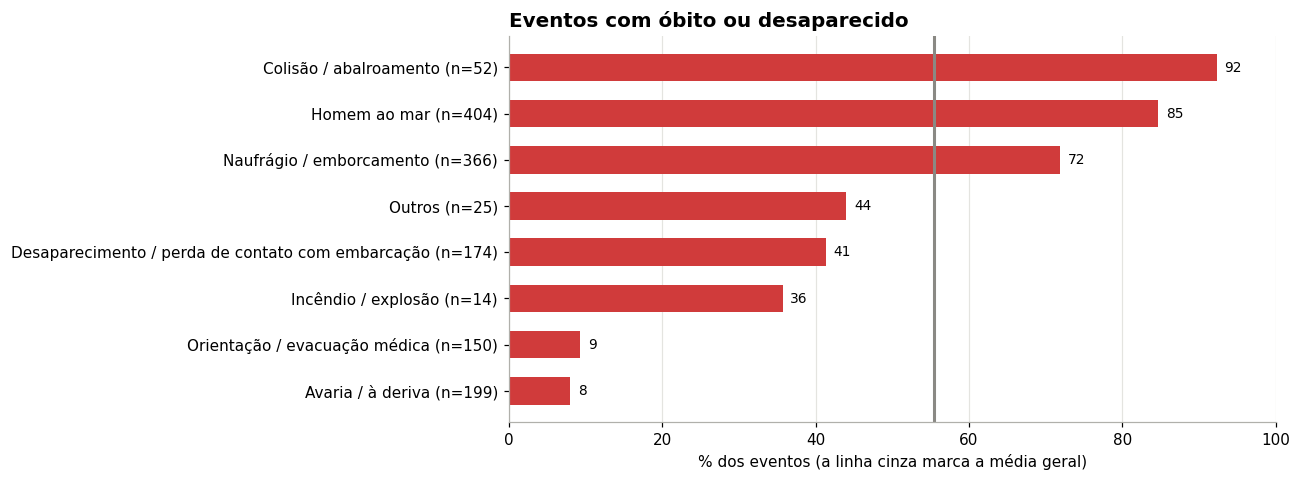

In [25]:
def grafico_eventos_graves(resumo, titulo_arquivo):
    """Barras horizontais com a proporção de eventos com vítima e a média geral (Figuras 6 e 7)."""
    resumo = resumo[resumo["eventos"] >= MINIMO_EVENTOS].iloc[::-1]  # maior no topo
    rotulos = [f"{nome} (n={n})" for nome, n in zip(resumo.index, resumo["eventos"])]

    fig, ax = plt.subplots(figsize=(9, 0.42 * len(resumo) + 1.2))
    ax.barh(rotulos, resumo["pct_eventos_graves"], color=COR_GRAVE, height=0.6)
    for posicao, valor in enumerate(resumo["pct_eventos_graves"]):
        ax.text(valor + 1, posicao, f"{valor:.0f}", va="center", fontsize=9)
    ax.axvline(geral["pct_eventos_graves"], color="#8a8984", linewidth=2)
    ax.set_xlim(0, 100)
    ax.set_xlabel("% dos eventos (a linha cinza marca a média geral)")
    ax.set_title("Eventos com óbito ou desaparecido")
    ax.grid(axis="x")
    ax.set_axisbelow(True)
    salvar_figura(fig, titulo_arquivo)
    plt.show()


# Figura 6 — por tipo de incidente
grafico_eventos_graves(por_tipo, "figura6_eventos_graves_por_tipo")

### Figura 7 — A mesma medida por classe de embarcação

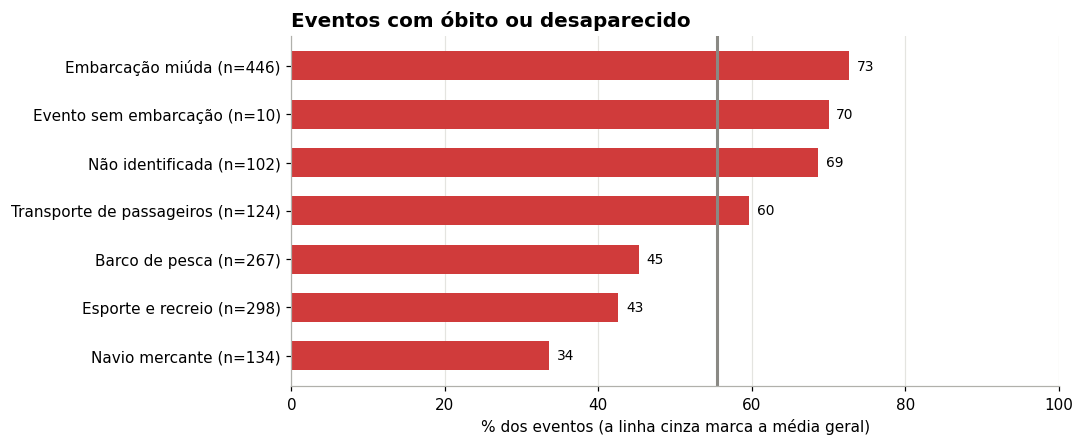

,eventos,pct_eventos_graves,pct_pessoas_salvas
classe_embarcacao,,,
Embarcação miúda,446,73,65
Evento sem embarcação,10,70,36
Não identificada,102,69,68
Transporte de passageiros,124,60,66
Barco de pesca,267,45,78
Esporte e recreio,298,43,86
Navio mercante,134,34,76


In [26]:
por_classe = duas_medidas(df, "classe_embarcacao")
grafico_eventos_graves(por_classe, "figura7_eventos_graves_por_classe")

tabela_classe = por_classe[por_classe["eventos"] >= MINIMO_EVENTOS][
    ["eventos", "pct_eventos_graves", "pct_pessoas_salvas"]].round(0).astype(int)
salvar_tabela(tabela_classe, "medidas_por_classe_de_embarcacao")
tabela_classe

### Por Salvamar

Números citados no texto da seção 5.3: os Salvamares de águas interiores (NOROESTE, OESTE e CENTRO-OESTE) têm as maiores proporções de eventos com vítima, e o NOROESTE tem a menor proporção de pessoas salvas.

In [27]:
por_salvamar = duas_medidas(df, "salvamar")[["eventos", "pct_eventos_graves", "pct_pessoas_salvas"]].round(0).astype(int)
salvar_tabela(por_salvamar, "medidas_por_salvamar")
por_salvamar

,eventos,pct_eventos_graves,pct_pessoas_salvas
salvamar,,,
SALVAMAR NOROESTE,137,87,54
SALVAMAR OESTE,44,82,64
SALVAMAR CENTRO-OESTE,34,71,72
SALVAMAR NORTE,253,68,71
SALVAMAR SUL-SUESTE,223,59,70
SALVAMAR SUL,142,59,62
SALVAMAR LESTE,144,37,87
SALVAMAR NORDESTE,129,36,72
SALVAMAR SUESTE,285,36,86


## 5.4 Duração e situação final dos eventos

### Figura 8 — Distribuição da duração, em dias, dentro de cada situação final

Cada barra mostra a porcentagem dentro da própria situação, porque há muito mais eventos encerrados do que suspensos.

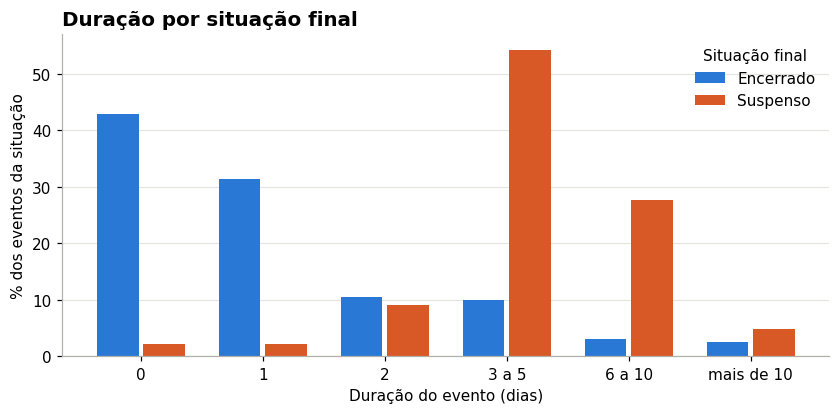

duracao,0,1,2,3 a 5,6 a 10,mais de 10
situacao_evento,,,,,,
Encerrado,42.8,31.3,10.4,9.9,3.0,2.6
Suspenso,2.1,2.1,9.0,54.3,27.7,4.8


In [28]:
LIMITES = [-1, 0, 1, 2, 5, 10, 10**6]
FAIXAS_DURACAO = ["0", "1", "2", "3 a 5", "6 a 10", "mais de 10"]

faixa = pd.cut(df["duracao"], bins=LIMITES, labels=FAIXAS_DURACAO)
distribuicao = 100 * pd.crosstab(df["situacao_evento"], faixa, normalize="index")
salvar_tabela(distribuicao.round(1), "figura8_duracao_por_situacao")

fig, ax = plt.subplots(figsize=(9, 3.8))
posicoes = np.arange(len(FAIXAS_DURACAO))
largura = 0.38
for deslocamento, (situacao, cor) in zip([-largura / 2, largura / 2],
                                         [("Encerrado", COR_SALVAS), ("Suspenso", COR_SUSPENSO)]):
    ax.bar(posicoes + deslocamento, distribuicao.loc[situacao], width=largura - 0.04,
           color=cor, label=situacao)
ax.set_xticks(posicoes, FAIXAS_DURACAO)
ax.set_xlabel("Duração do evento (dias)")
ax.set_ylabel("% dos eventos da situação")
ax.set_title("Duração por situação final")
ax.legend(title="Situação final", frameon=False)
ax.grid(axis="y")
ax.set_axisbelow(True)
salvar_figura(fig, "figura8_duracao_por_situacao")
plt.show()

distribuicao.round(1)

In [29]:
encerrados = df[df["situacao_evento"] == "Encerrado"]["duracao"]
suspensos = df[df["situacao_evento"] == "Suspenso"]["duracao"]

print(f"Encerrados que terminam no mesmo dia ou no dia seguinte: {100 * (encerrados <= 1).mean():.0f}% "
      f"(mediana de {encerrados.median():.0f} dia)")
print(f"Suspensos que duram de 3 a 10 dias: {100 * suspensos.between(3, 10).mean():.0f}% "
      f"(mediana de {suspensos.median():.0f} dias)")

Encerrados que terminam no mesmo dia ou no dia seguinte: 74% (mediana de 1 dia)
Suspensos que duram de 3 a 10 dias: 82% (mediana de 4 dias)


## Conferência com o relatório

Cada linha compara um valor publicado no relatório (versão de 28 de setembro de 2026) com o valor calculado acima. Os percentuais são arredondados como no texto.

In [30]:
def arredondado(valor):
    return int(round(float(valor)))


conferencia = pd.DataFrame([
    ("1.4", "Eventos SAR", 1391, total_eventos),
    ("1.4", "Sobreviventes", 3202, df["sobreviventes"].sum()),
    ("1.4", "Vidas salvas", 3031, df["vidas_salvas"].sum()),
    ("1.4", "Vidas salvas por meios da MB", 978, df["salvas_mb"].sum()),
    ("1.4", "Vidas salvas por meios extra-MB", 2053, df["salvas_extra_mb"].sum()),
    ("1.4", "Sobreviventes sem resgate", 171, df["sem_resgate"].sum()),
    ("1.4", "Óbitos", 821, df["obitos"].sum()),
    ("1.4", "Desaparecidos", 260, df["desaparecidos"].sum()),
    ("1.4", "Eventos com óbito ou desaparecido", 771, eventos_graves),
    ("3.2", "Alterações documentadas", 659, len(registro)),
    ("3.2", "Colunas da aba Base de dados", 83, base.shape[1]),
    ("3.3", "Eventos encerrados", 1203, (df["situacao_evento"] == "Encerrado").sum()),
    ("3.3", "Eventos suspensos", 188, (df["situacao_evento"] == "Suspenso").sum()),
    ("3.3", "Eventos com ciclos sucessivos", 23, df["ciclos"].notna().sum()),
    ("3.4", "Combinações ano x DN iguais ao ANEMAR", 45, iguais),
    ("3.4", "Eventos conferidos com o relatório final", 1216, conferidos),
    ("3.4", "Eventos com posição aproximada", 3, (df["situacao_coordenada"] != "OK").sum()),
    ("3.5", "Eventos somente com sobreviventes", 558, grupos["Somente sobreviventes"]),
    ("3.5", "Eventos sem registro de pessoas", 62, grupos["Sem registro de pessoas"]),
    ("5.1", "Eventos em fevereiro (menor mês)", 98, por_mes["Fev"]),
    ("5.1", "Eventos em outubro (maior mês)", 136, por_mes["Out"]),
    ("5.2", "Áreas de 0,5° com ocorrência", 577, len(celulas)),
    ("5.2", "Áreas com eventos nos cinco anos", 23, len(recorrentes)),
    ("5.2", "Eventos nas áreas recorrentes", 315, eventos_recorrentes),
    ("5.3", "Eventos com óbito ou desaparecido (%)", 55, arredondado(geral["pct_eventos_graves"])),
    ("5.3", "Pessoas salvas (%)", 75, arredondado(geral["pct_pessoas_salvas"])),
    ("5.4", "Encerrados em até 1 dia (%)", 74, arredondado(100 * (encerrados <= 1).mean())),
    ("5.4", "Mediana dos encerrados (dias)", 1, encerrados.median()),
    ("5.4", "Suspensos entre 3 e 10 dias (%)", 82, arredondado(100 * suspensos.between(3, 10).mean())),
    ("5.4", "Mediana dos suspensos (dias)", 4, suspensos.median()),
], columns=["Seção", "Item", "Relatório", "Calculado"])

conferencia["Calculado"] = conferencia["Calculado"].astype(int)
conferencia["Confere"] = np.where(conferencia["Relatório"] == conferencia["Calculado"], "sim", "NÃO")
print(f"{(conferencia['Confere'] == 'sim').sum()} de {len(conferencia)} valores conferem com o relatório.")
conferencia

30 de 30 valores conferem com o relatório.


,Seção,Item,Relatório,Calculado,Confere
0,1.4,Eventos SAR,1391,1391,sim
1,1.4,Sobreviventes,3202,3202,sim
2,1.4,Vidas salvas,3031,3031,sim
3,1.4,Vidas salvas por meios da MB,978,978,sim
4,1.4,Vidas salvas por meios extra-MB,2053,2053,sim
5,1.4,Sobreviventes sem resgate,171,171,sim
6,1.4,Óbitos,821,821,sim
7,1.4,Desaparecidos,260,260,sim
8,1.4,Eventos com óbito ou desaparecido,771,771,sim
9,3.2,Alterações documentadas,659,659,sim
